# Prompt Generation for LLM Fine-tuning

This notebook generates structured training examples from `first_innings_sections_clean` for LLM fine-tuning.

Each row is converted into a natural-language prompt describing the in-game state at a given section boundary, with the target label being the `final_innings_score`. Outputs are saved as a JSONL file.

In [1]:
import sqlite3
import json
from pathlib import Path

current_dir = Path().resolve()
project_root = current_dir.parent if current_dir.name == 'research' else current_dir
db_path = str(project_root / 't20s_json' / 'venue_metrics.db')

conn = sqlite3.connect(db_path)
conn.row_factory = sqlite3.Row

print(f"Connected to: {db_path}")

# Verify table exists and check row count
count = conn.execute("SELECT COUNT(*) FROM first_innings_sections_clean").fetchone()[0]
print(f"Rows in first_innings_sections_clean: {count}")

Connected to: /Users/damith/projects/t20_score_prediction/t20s_json/venue_metrics.db
Rows in first_innings_sections_clean: 28954


In [2]:
def build_prompt(row) -> str:
    powerplay_str = "Yes" if row["powerplay_completed"] else "No"
    return (
        f"Match type: T20\n"
        f"Venue: {row['venue']}\n"
        f"Venue par score: {row['par_score_filled']}\n"
        f"Batting team: {row['team']}\n"
        f"\n"
        f"Overs completed: {row['overs_completed']}\n"
        f"Balls remaining: {row['balls_remaining']}\n"
        f"Runs scored: {row['cumulative_runs']}\n"
        f"Wickets lost: {row['cumulative_wickets']}\n"
        f"Current run rate: {row['cumulative_run_rate_rounded']}\n"
        f"\n"
        f"Runs in last 2 overs: {row['runs_in_section']}\n"
        f"Dot balls so far: {row['dot_balls_so_far']}\n"
        f"Dot balls in last 2 overs: {row['dot_balls_last_2_overs']}\n"
        f"\n"
        f"Fours hit: {row['fours_hit']}\n"
        f"Sixes hit: {row['sixes_hit']}\n"
        f"\n"
        f"Powerplay completed: {powerplay_str}\n"
        f"\n"
        f"Remaining Batting Strength Score: {row['remaining_batting_strength_score']}\n"
        f"\n"
        f"Final 1st innings score:"
    )


rows = conn.execute("""
    SELECT
        team, venue, overs_completed, balls_remaining,
        cumulative_runs, cumulative_wickets, cumulative_run_rate_rounded,
        runs_in_section, dot_balls_so_far, dot_balls_last_2_overs,
        fours_hit, sixes_hit, powerplay_completed,
        remaining_batting_strength_score, final_innings_score,
        par_score_filled
    FROM first_innings_sections_clean
""").fetchall()

records = []
for row in rows:
    records.append({
        "prompt": build_prompt(row),
        "completion": str(row["final_innings_score"])
    })

print(f"Generated {len(records)} training examples")
print("\n--- Sample prompt ---")
print(records[0]["prompt"])
print(f"\n--- Completion ---")
print(records[0]["completion"])

Generated 28954 training examples

--- Sample prompt ---
Match type: T20
Venue: Simonds Stadium, South Geelong
Venue par score: 173.0
Batting team: Australia

Overs completed: 2
Balls remaining: 108
Runs scored: 17
Wickets lost: 0
Current run rate: 8.5

Runs in last 2 overs: 17
Dot balls so far: 4
Dot balls in last 2 overs: 4

Fours hit: 2
Sixes hit: 0

Powerplay completed: No

Remaining Batting Strength Score: 6.7

Final 1st innings score:

--- Completion ---
173


In [3]:
output_path = project_root / 't20s_json' / 'finetune_training_data.jsonl'

with open(output_path, 'w') as f:
    for record in records:
        f.write(json.dumps(record) + '\n')

print(f"Saved {len(records)} records to: {output_path}")

Saved 28954 records to: /Users/damith/projects/t20_score_prediction/t20s_json/finetune_training_data.jsonl


In [13]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

load_dotenv(override=True)
hf_token = os.environ.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

BASE_MODEL = "meta-llama/Llama-3.2-3B"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
print(f"Loaded tokenizer for: {BASE_MODEL}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loaded tokenizer for: meta-llama/Llama-3.2-3B


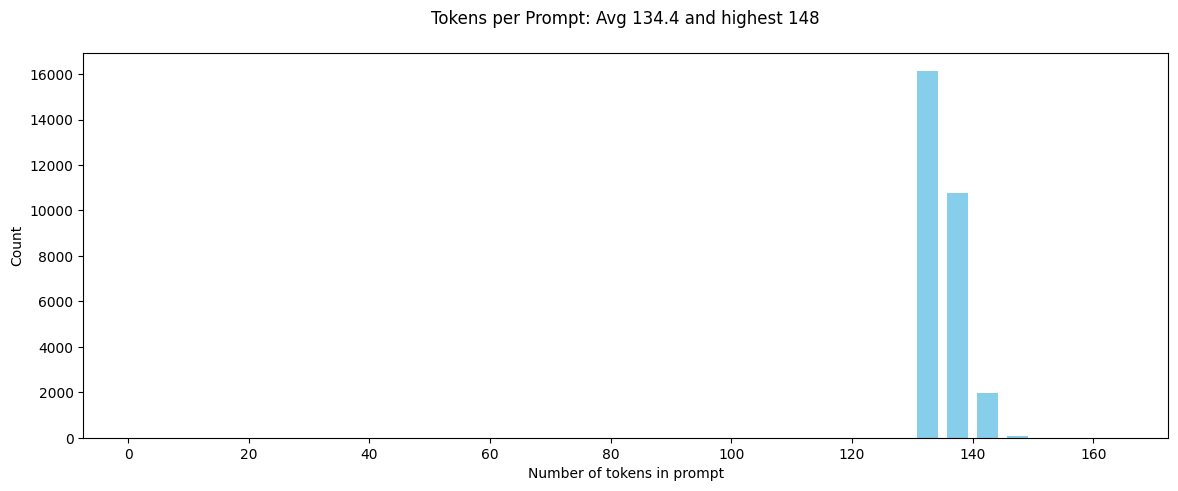

Min: 130, Max: 148, Avg: 134.4


In [14]:
token_counts = [len(tokenizer.encode(r["prompt"])) for r in records]

avg_tokens = sum(token_counts) / len(token_counts)
max_tokens = max(token_counts)

plt.figure(figsize=(14, 5))
plt.title(f"Tokens per Prompt: Avg {avg_tokens:,.1f} and highest {max_tokens:,}\n")
plt.xlabel("Number of tokens in prompt")
plt.ylabel("Count")
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, max_tokens + 20, 5))
plt.show()

print(f"Min: {min(token_counts)}, Max: {max_tokens}, Avg: {avg_tokens:.1f}")

171. Day 2 - Fine-Tuning Data Prep: Rounding Prices and Token Length Optimization 

why choose LLAMA

Given your distribution, the data is heavily skewed toward recent years (~55% of all matches are from 2022–2025). Here's the recommended split based on clean year boundaries:

Split	Years	Matches	%
Train	2005–2023	1,834	63.6%
Validation	2024	574	19.9%
Test	2025–2026	474	16.4%
This works well because:

2024 as validation — large enough (574 matches) to give reliable validation signal during training
2025 as test — the most recent complete year, best reflects real-world deployment
The train set still includes 2021 (270), 2022 (404), 2023 (328) — 1,002 recent matches — so the model sees modern T20 conditions
If you want more training data, an alternative is:

Split	Years	Matches	%
Train	2005–2024	2,408	83.6%
Validation	Jan–Jun 2025	~237	~8%
Test	Jul–Dec 2025 + 2026	~237	~8%
This requires splitting 2025 by date rather than by year.

One caution: the pre-2019 data (only 577 matches across 14 years) reflects a very different era of T20 cricket — different playing conditions, team compositions, and strategies. You may want to drop pre-2015 data (only 159 matches) or at minimum verify it doesn't hurt model performance, since older match patterns may not generalise to modern T20 scoring.

In [4]:
from datasets import Dataset, DatasetDict

# Re-fetch records with the date column for splitting
rows_with_date = conn.execute("""
    SELECT
        date, team, venue, overs_completed, balls_remaining,
        cumulative_runs, cumulative_wickets, cumulative_run_rate_rounded,
        runs_in_section, dot_balls_so_far, dot_balls_last_2_overs,
        fours_hit, sixes_hit, powerplay_completed,
        remaining_batting_strength_score, final_innings_score,
        par_score_filled
    FROM first_innings_sections_clean
    ORDER BY date
""").fetchall()

def build_record(row):
    return {
        "date": row["date"],
        "prompt": build_prompt(row),
        "completion": str(row["final_innings_score"])
    }

all_records = [build_record(r) for r in rows_with_date]

# Split by date boundary
# Train:      up to 2024-12-31
# Validation: 2025-01-01 – 2025-06-30
# Test:       2025-07-01 onwards

train_records = [r for r in all_records if r["date"] <= "2024-12-31"]
val_records   = [r for r in all_records if "2025-01-01" <= r["date"] <= "2025-06-30"]
test_records  = [r for r in all_records if r["date"] >= "2025-07-01"]

print(f"Train : {len(train_records):,} rows  (up to 2024-12-31)")
print(f"Val   : {len(val_records):,} rows  (2025-01-01 – 2025-06-30)")
print(f"Test  : {len(test_records):,} rows  (2025-07-01+)")

# Strip the date field before building HuggingFace datasets
def drop_date(records):
    return [{"prompt": r["prompt"], "completion": r["completion"]} for r in records]

dataset = DatasetDict({
    "train":      Dataset.from_list(drop_date(train_records)),
    "validation": Dataset.from_list(drop_date(val_records)),
    "test":       Dataset.from_list(drop_date(test_records)),
})

print(f"\nDatasetDict:\n{dataset}")

/Users/damith/projects/t20_score_prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train : 24,123 rows  (up to 2024-12-31)
Val   : 1,614 rows  (2025-01-01 – 2025-06-30)
Test  : 3,217 rows  (2025-07-01+)

DatasetDict:
DatasetDict({
    train: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 24123
    })
    validation: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 1614
    })
    test: Dataset({
        features: ['prompt', 'completion'],
        num_rows: 3217
    })
})


In [5]:
username = "ratnayakatilanka"
hf_dataset_name = f"{username}/t20_score_prediction_prompts"

dataset.push_to_hub(hf_dataset_name)
print(f"Uploaded to: https://huggingface.co/datasets/{hf_dataset_name}")

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 62.43ba/s]
Processing Files (1 / 1): 100%|██████████| 1.22MB / 1.22MB,  191kB/s  
New Data Upload: 100%|██████████| 1.22MB / 1.22MB,  191kB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:08<00:00,  8.13s/ shards]
Setting num_proc from 1 back to 1 for the validation split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 470.16ba/s]
Processing Files (1 / 1): 100%|██████████| 85.8kB / 85.8kB, 42.9kB/s  
New Data Upload: 100%|██████████| 85.8kB / 85.8kB, 42.9kB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:03<00:00,  3.12s/ shards]
Setting num_proc from 1 back to 1 for the test split to disable multiprocessing as it only contains one shard.
Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:

Uploaded to: https://huggingface.co/datasets/ratnayakatilanka/t20_score_prediction_prompts
